# Best Model: EfficientNet

🎯 **Goal**: Rebuild and validate the best-performing EfficientNetB0 models from earlier experiments, and save them as reproducible artefacts.

Approach:

- Recreate the EfficientNetB0 frozen model using the established pipeline
- Apply fine-tuning (top layers) to test for additional gains
- Use early stopping to select best-performing weights
- Track runs and metrics with MLflow
- Save both models (frozen + fine-tuned) for reuse and deployment

### Executive Summary

This notebook rebuilds the best-performing models identified during earlier transfer learning experiments, focusing on EfficientNetB0.

The frozen EfficientNetB0 model achieves ~65% validation accuracy, representing a significant improvement over earlier architectures. Fine-tuning the top layers provides a small additional gain, increasing validation accuracy to ~66%, while test performance remains broadly unchanged at ~ 66.9%.

👉 Overall, results confirm that EfficientNetB0 is the strongest backbone tested, with fine-tuning offering only marginal improvement. Both models are saved as reproducible artefacts for downstream evaluation and use.

### Imports

In [1]:
import os
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import mlflow

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

from beakspeak.data import load_metadata, split_data, create_dataset
from beakspeak.models import build_transfer_learning_model
from beakspeak.params import (
    IMG_HEIGHT,
    IMG_WIDTH,
    BATCH_SIZE,
    LEARNING_RATE,
    SEED,
    NUM_CLASSES
)

# --- MLFlow setup ---
PROJECT_ROOT = Path.cwd().parent
MLFLOW_DB = PROJECT_ROOT / "mlruns.db"
MLRUNS_DIR = PROJECT_ROOT / "mlruns"

MLRUNS_DIR.mkdir(exist_ok=True)

mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_DB.resolve()}")

MLFLOW_EXPERIMENT_NAME = "efficientnet-best"

experiment = mlflow.get_experiment_by_name(MLFLOW_EXPERIMENT_NAME)

if experiment is None:
    mlflow.create_experiment(
        MLFLOW_EXPERIMENT_NAME,
        artifact_location=MLRUNS_DIR.resolve().as_uri()
    )

mlflow.set_experiment(MLFLOW_EXPERIMENT_NAME)

# --- Paths ---
DATA_DIR = Path("../data/CUB_200_2011/CUB_200_2011")

MODEL_DIR = Path.cwd().parent / "models"
MODEL_DIR.mkdir(exist_ok=True)

# --- tf performance ---
AUTOTUNE = tf.data.AUTOTUNE

In [2]:
# MLFlow helper functions

def plot_and_log_curves(history):
    import matplotlib.pyplot as plt
    import mlflow

    # --- extract metrics ---
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs_range = range(len(acc))

    # --- Accuracy plot ---
    plt.figure()
    plt.plot(epochs_range, acc, label="Train Accuracy")
    plt.plot(epochs_range, val_acc, label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.title("Accuracy Curve")

    plt.savefig("accuracy_curve.png")
    mlflow.log_artifact("accuracy_curve.png")
    plt.close()

    # --- Loss plot ---
    plt.figure()
    plt.plot(epochs_range, loss, label="Train Loss")
    plt.plot(epochs_range, val_loss, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Loss Curve")

    plt.savefig("loss_curve.png")
    mlflow.log_artifact("loss_curve.png")
    plt.close()

def log_run_params(
    backbone,
    stage,
    frozen_base,
    learning_rate,
    epochs,
    early_stopping=False,
    early_stopping_patience=None,
    batchnorm_frozen=None,
    fine_tune_at=None,
    augmentation=None,
):
    """
    Log a consistent set of MLflow parameters for model runs.
    Optional params are only logged when relevant.
    """
    params = {
        "backbone": backbone,
        "stage": stage,
        "frozen_base": frozen_base,
        "learning_rate": learning_rate,
        "epochs": epochs,
        "early_stopping": early_stopping,
        "early_stopping_patience": early_stopping_patience,
    }

    # Only include optional params if relevant
    if batchnorm_frozen is not None:
        params["batchnorm_frozen"] = batchnorm_frozen

    if fine_tune_at is not None:
        params["fine_tune_at"] = fine_tune_at

    if augmentation is not None:
        params["augmentation"] = augmentation


    mlflow.log_params(params)

In [3]:
# Helper function to plot performance in notebook

def plot_training_history(history):
    """
    Plot training vs validation accuracy and loss from a Keras History object.
    """

    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]

    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs = range(len(acc))

    plt.figure(figsize=(12, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label="Train Accuracy")
    plt.plot(epochs, val_acc, label="Validation Accuracy")
    plt.title("Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label="Train Loss")
    plt.plot(epochs, val_loss, label="Validation Loss")
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

## Load the data

In [4]:
# Load and split the data
metadata_df = load_metadata(DATA_DIR)
train_df, val_df, test_df = split_data(metadata_df)

In [5]:
# Prepare labels for tf
train_df["label"] = train_df["class_id"] - 1
val_df["label"] = val_df["class_id"] - 1
test_df["label"] = test_df["class_id"] - 1

In [6]:
# Create train, test, val datasets
train_ds = create_dataset(train_df, shuffle=True, scaling=False)
val_ds = create_dataset(val_df, shuffle=False, scaling=False)
test_ds = create_dataset(test_df, shuffle=False, scaling=False)

## Recreate and save best models

In [7]:
# Build and compile EfficientNetB0 model
efficient_model = build_transfer_learning_model(
    num_classes=NUM_CLASSES,
    backbone="EfficientNetB0",
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

efficient_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

efficient_model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 200)            │        25,800 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,239,339 (16.17 MB)

 Trainable params: 189,768 (741.28 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

### EfficientNetB0 Base

Epoch 1/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 55s 347ms/step - accuracy: 0.0986 - loss: 4.4034 - val_accuracy: 0.3353 - val_loss: 2.9590
Epoch 2/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 51s 338ms/step - accuracy: 0.3512 - loss: 2.5572 - val_accuracy: 0.4871 - val_loss: 2.0624
Epoch 3/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 53s 351ms/step - accuracy: 0.4907 - loss: 1.8850 - val_accuracy: 0.5363 - val_loss: 1.7425
Epoch 4/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 58s 387ms/step - accuracy: 0.5654 - loss: 1.5638 - val_accuracy: 0.5771 - val_loss: 1.5682
Epoch 5/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 425s 3s/step - accuracy: 0.6269 - loss: 1.3232 - val_accuracy: 0.5972 - val_loss: 1.4802
Epoch 6/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 49s 328ms/step - accuracy: 0.6680 - loss: 1.1538 - val_accuracy: 0.6138 - val_loss: 1.4300
Epoch 7/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 50s 331ms/step - accuracy: 0.7074 - loss: 1.0411 - val_accuracy: 0.6230 - val_loss: 1.3834
Epoch 8/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 52s 346ms/step - accuracy: 0.7381 - loss: 0.9

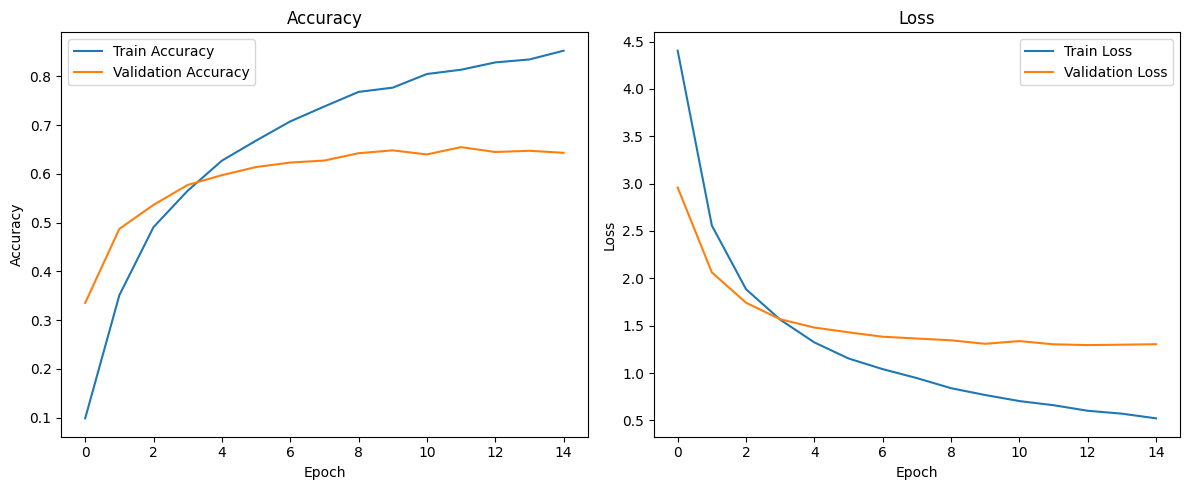

In [ ]:
efficient_base = efficient_model.layers[1]  # Assu

# Train the model and log metrics with MLFlow
with mlflow.start_run(run_name="efficientnetb0_best"):
    log_run_params(
        backbone="EfficientNetB0",
        stage="frozen",
        frozen_base=False,
        learning_rate=LEARNING_RATE,
        epochs=15,
        early_stopping=True,
        early_stopping_patience=3,
    )

    # Early stopping callback
    early_stopping_cb = EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )

    # Train the model
    efficient_model_history = efficient_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=15,
        callbacks=[early_stopping_cb]
    )

    # Save model
    MODEL_PATH = MODEL_DIR / "efficientnetb0_best.keras"
    efficient_model.save(MODEL_PATH)
    print(f"✅ Model saved to {MODEL_PATH}")

    # Log performance curves
    plot_and_log_curves(efficient_model_history)
    print("✅ Training curves logged to MLFlow.")

    # Evaluate on test and validation sets
    test_loss, test_acc = efficient_model.evaluate(test_ds)
    val_loss, val_acc = efficient_model.evaluate(val_ds)

    best_val_acc = max(efficient_model_history.history["val_accuracy"])
    best_val_loss = min(efficient_model_history.history["val_loss"])

    mlflow.log_metrics({
        "test_loss": test_loss,
        "test_accuracy": test_acc,
        "val_loss": val_loss,
        "val_accuracy": val_acc,
        "best_val_accuracy": best_val_acc,
        "best_val_loss": best_val_loss
    })

    print(f"Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}, Validation Loss: {val_loss:.4f}")
    print(f"Best Validation Accuracy: {best_val_acc:.4f}, Best Validation Loss: {best_val_loss:.4f}")
    print(f"Best Validation Loss: {best_val_loss:.4f}")
    print("✅ Metrics logged to MLFlow.")

    # Plot training history in notebook
    plot_training_history(efficient_model_history)

### EfficientNetB0 Fine Tuned

In [10]:
efficient_base = efficient_model.layers[1]
efficient_base.trainable = True
fine_tune_at = len(efficient_base.layers) - 30

# Freeze all layers before the fine-tune point
for i, layer in enumerate(efficient_base.layers):
    if i < fine_tune_at:
        layer.trainable = False
    else:
        # Keep BatchNorm layers frozen to prevent training instability
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False
        else:
            layer.trainable = True

# Count trainable vs non-trainable weights
print("Trainable weights:", len(efficient_model.trainable_weights))
print("Non-trainable weights:", len(efficient_model.non_trainable_weights))

Trainable weights: 18
Non-trainable weights: 298


Epoch 1/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 60s 378ms/step - accuracy: 0.8505 - loss: 0.5338 - val_accuracy: 0.6472 - val_loss: 1.2903
Epoch 2/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 55s 368ms/step - accuracy: 0.8521 - loss: 0.5248 - val_accuracy: 0.6489 - val_loss: 1.2870
Epoch 3/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 58s 388ms/step - accuracy: 0.8561 - loss: 0.5114 - val_accuracy: 0.6522 - val_loss: 1.2847
Epoch 4/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 67s 449ms/step - accuracy: 0.8619 - loss: 0.5057 - val_accuracy: 0.6522 - val_loss: 1.2828
Epoch 5/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 66s 437ms/step - accuracy: 0.8630 - loss: 0.4918 - val_accuracy: 0.6530 - val_loss: 1.2818
Epoch 6/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 64s 426ms/step - accuracy: 0.8576 - loss: 0.4959 - val_accuracy: 0.6547 - val_loss: 1.2807
Epoch 7/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 64s 425ms/step - accuracy: 0.8619 - loss: 0.4907 - val_accuracy: 0.6555 - val_loss: 1.2803
Epoch 8/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 64s 425ms/step - accuracy: 0.8607 - loss: 0

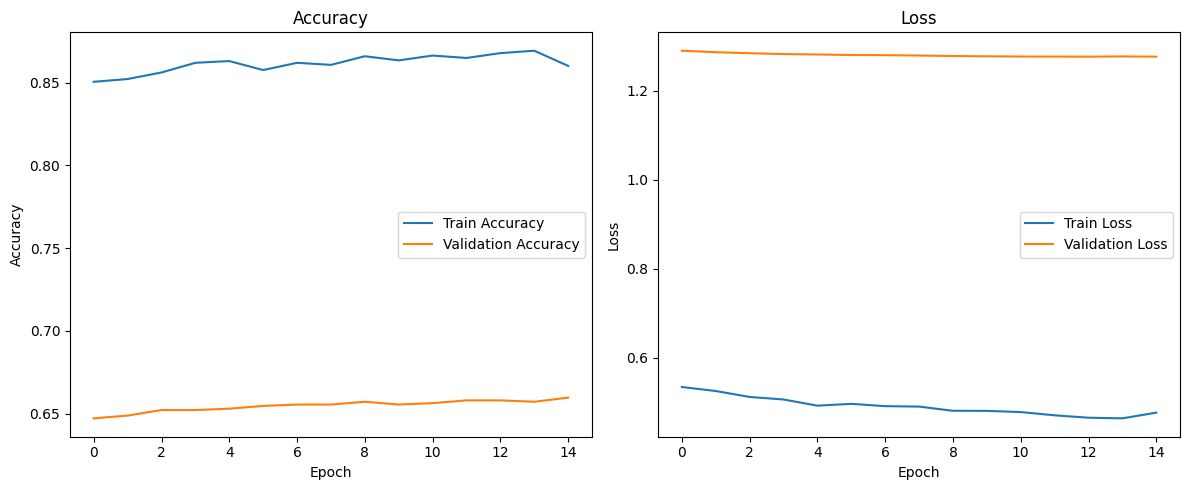

In [11]:
# Recompile the model with a lower learning rate for fine-tuning
FINE_TUNE_LEARNING_RATE = 1e-5
FINE_TUNE_EPOCHS = 15

efficient_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=FINE_TUNE_LEARNING_RATE / 10),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

# Train the model and log metrics with MLFlow
with mlflow.start_run(run_name="efficientnetb0_fine_tune"):
    log_run_params(
        backbone="EfficientNetB0",
        stage="fine-tune",
        frozen_base=False,
        learning_rate=FINE_TUNE_LEARNING_RATE,
        epochs=FINE_TUNE_EPOCHS,
        early_stopping=True,
        early_stopping_patience=3,
        fine_tune_at=fine_tune_at,
        batchnorm_frozen=True
    )

    # Train the model
    efficient_fine_tune_history = efficient_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=FINE_TUNE_EPOCHS,
        callbacks=[early_stopping_cb]
    )

    # Save model
    FINE_TUNE_MODEL_PATH = MODEL_DIR / "efficientnetb0_fine_tuned.keras"
    efficient_model.save(FINE_TUNE_MODEL_PATH)
    print(f"✅ Fine-tuned model saved to {FINE_TUNE_MODEL_PATH}")

    # Log performance curves
    plot_and_log_curves(efficient_fine_tune_history)
    print("✅ Fine-tuning curves logged to MLFlow.")

    # Evaluate on test and validation sets
    test_loss, test_acc = efficient_model.evaluate(test_ds)
    val_loss, val_acc = efficient_model.evaluate(val_ds)

    best_val_acc = max(efficient_fine_tune_history.history["val_accuracy"])
    best_val_loss = min(efficient_fine_tune_history.history["val_loss"])

    mlflow.log_metrics({
        "test_loss": test_loss,
        "test_accuracy": test_acc,
        "val_loss": val_loss,
        "val_accuracy": val_acc,
        "best_val_accuracy": best_val_acc,
        "best_val_loss": best_val_loss
    })

    print(f"Fine-tuned Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")
    print(f"Fine-tuned Validation Accuracy: {val_acc:.4f}, Validation Loss: {val_loss:.4f}")
    print(f"Fine-tuned Best Validation Accuracy: {best_val_acc:.4f}, Best Validation Loss: {best_val_loss:.4f}")
    print(f"Fine-tuned Best Validation Loss: {best_val_loss:.4f}")
    print("✅ Fine-tuning metrics logged to MLFlow.")

    # Plot fine-tuning history in notebook
    plot_training_history(efficient_fine_tune_history)

### 🙋‍♀️ EfficientNetB0 fine-tuning: Marginal improvements only

Fine-tuning the top 30 layers of EfficientNetB0 produces only a very small improvement over the frozen model. Best validation accuracy increases to ~66.0%, while test accuracy remains effectively unchanged at ~66.9%.

Validation loss does improve slightly, suggesting the fine-tuned model is fitting the task a little better, but the overall impact is limited.

This indicates that most of the performance gain is coming from the EfficientNetB0 backbone itself, rather than from additional adaptation through fine-tuning. In other words, backbone choice is the main lever, while fine-tuning provides only marginal benefit in this setup.

👉 For this project, fine-tuning helps a little, but does not materially change the overall conclusion.

#### What’s next

With a strong baseline established, the focus now shifts from improving accuracy to understanding model behaviour:

- **Confusion matrix**: identify which bird species are most frequently misclassified
- **Error analysis**: inspect incorrect predictions to spot patterns (e.g. visually similar species, lighting, pose)
- **Top-k accuracy** (e.g. top 3): assess whether the correct species is among the model’s likely candidates
- **Class-level performance**: check whether certain species consistently underperform

The goal is to move beyond a single accuracy number and understand where the model succeeds and fails, which can inform whether further improvements should focus on data, modelling, or problem framing.